# Color Sensor for the Determination of the Ripening Stage of Cherry Tomatoes — Colab Reproduction

**Paper:** *Color Sensor for the Determination of the Ripening Stage of Cherry Tomatoes*
(V. A. Pinheiro, A. P. Garcia, D. Albiero, T. Q. Z. Cesar, C. K. Umezu, E. F. Nunes)
**Data & code:** Zenodo DOI [10.5281/zenodo.23067950](https://doi.org/10.5281/zenodo.23067950) · GitHub [vandeiraniceto/color_sensor_tomatoes](https://github.com/vandeiraniceto/color_sensor_tomatoes) pinned at commit `2678cf686f30` (MIT license).

## Scope and execution status

This notebook reproduces the **software subsection** of the paper on the authors' released dataset:

1. **Preprocessing** — average the triplicated readings, convert sensor RGB → CIELAB (`1_convertNewDataset.py`),
   and **verify the result against the authors' released `dataset.csv`** (expected: exact match).
2. **Ground-truth labeling** — K-Means (k=3, ordered by a*) → Unripe / Medium / Ripe (`2_classificar_maturidade.py`),
   **verified against the released `dataset_classificado.csv`** (expected: exact label match).
3. **Calibration** — retrain the multivariate linear regression (sensor-RGB-derived LAB → reference LAB) with 5-fold
   cross-validation and **compare the coefficients with the values pinned in the authors' C header**.
4. **MCU decision tree** — retrain the entropy, depth-3 tree and **compare the split thresholds with the authors'
   pruned firmware rules** (L*≤40.79, a*≤−1.58, b*>24.84).
5. **End-to-end pipeline evaluation** — replicate `final_pipeline_evaluation_atmega.ipynb` with both the authors'
   verbatim pinned artifacts and our retrained models, and compare with the authors' saved notebook outputs.

> **Important known discrepancy (verified from the authors' saved outputs):** every author notebook output in the
> release was produced from a **119-record** dataset version, while the released spreadsheet/CSVs contain **130
> records** (see §8). Steps 1–2 regenerate the *released* files exactly, but retraining on the released data
> therefore cannot coincide with the pinned coefficients/thresholds or the headline metrics (reported as
> 84.03% / 99.16% / 31.09%, i.e. exactly 100/119, 118/119 and 37/119). This notebook quantifies both.

**Runtime: CPU only.** No GPU appears anywhere in the authors' pipeline (linear regression, K-Means and a depth-3
decision tree on 130 samples); select **Runtime → Change runtime type → CPU** (or leave the default).
Expected end-to-end time: a few minutes; downloads < 1 MB. *日本語: このノートブックは CPU のみで実行できます（GPU 不要）。
所要時間は数分、ダウンロードは 1 MB 未満です。*

**Not reproduced (out of software scope):** the physical sensor node, 915 MHz RF telemetry, hardware assembly
(the README's `prototype_device/` designs are absent from the released repository tree) and firmware flashing.
The publication itself is an abstract-level Zenodo deposit; every method parameter used here comes from the
authors' pinned code and saved outputs, not from the abstract. *日本語: ハードウェア（センサノード・RF通信・組込み実行）は対象外です。*


## 0. Environment setup

The authors list `pandas numpy scikit-learn scikit-image matplotlib seaborn openpyxl` as requirements.
Colab preinstalls most of them; we install only the two that may be missing (`openpyxl` for the Excel
reader, `scikit-image` for the CIE D65 / 2°-observer `rgb2lab` conversion) and print the versions actually
used so the run is reproducible. *日本語: 著者の依存パッケージのうち Colab に無い可能性がある 2 つのみ追加インストールし、
使用したバージョンを表示します。*


In [ ]:
%pip install -q openpyxl scikit-image

import numpy as np, pandas as pd, sklearn, skimage, matplotlib, seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
import pathlib, hashlib, json, urllib.request

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("scikit-image", skimage.__version__)
print("matplotlib  ", matplotlib.__version__)
print("seaborn     ", seaborn.__version__)

numpy        2.1.3
pandas       2.2.3
scikit-learn 1.6.1
scikit-image 0.25.2
matplotlib   3.10.0
seaborn      0.13.2


## 1. Input acquisition (pinned revision, Colab-only)

All inputs are dataset bytes and are downloaded **here in Colab** from the authors' repository at the verified
commit `2678cf686f305c80d3961b870cda5c0c32612156`. We call the public GitHub tree API **once** (recursive listing) for the exact commit to obtain
expected blob sizes and Git blob SHA-1 hashes, then download only the files this demonstration needs:

- `DADOS_COLETADO.xlsx` — raw triplicated sensor RGB + reference CIELAB readings with `ID_FOTO`
- `dataset.csv` — authors' released averaged dataset (reference output of Step 1)
- `dataset_classificado.csv` — authors' released labeled dataset (reference output of Step 2)
- three `photos_tomato/{ID}.jpg` sample photographs (selected deterministically after labeling, in §4)

Every download is validated: expected byte count, Git blob SHA-1 (`sha1("blob <size>\\0" + bytes)`), and parser
validity. *日本語: 入力データはすべて Colab 内でダウンロードし、Git blob ハッシュで検証します。*


In [ ]:
COMMIT = "2678cf686f305c80d3961b870cda5c0c32612156"
RAW = f"https://raw.githubusercontent.com/vandeiraniceto/color_sensor_tomatoes/{COMMIT}"

# One public tree-API call for the pinned commit (public repo -> no token needed)
tree_url = f"https://api.github.com/repos/vandeiraniceto/color_sensor_tomatoes/git/trees/{COMMIT}?recursive=1"
with urllib.request.urlopen(tree_url, timeout=60) as r:
    tree = json.load(r)
assert not tree.get("truncated"), "tree listing was truncated"
blob_index = {t["path"]: (t["size"], t["sha"]) for t in tree["tree"] if t["type"] == "blob"}
print(f"pinned tree: {len(blob_index)} blobs at commit {COMMIT[:12]}")

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

def fetch_pinned(path: str) -> bytes:
    size, sha = blob_index[path]
    with urllib.request.urlopen(f"{RAW}/{path}", timeout=120) as r:
        data = r.read()
    assert len(data) == size, f"{path}: {len(data)} bytes, expected {size}"
    assert git_blob_sha(data) == sha, f"{path}: Git blob SHA mismatch"
    return data

DATA = {}
for path in ["DADOS_COLETADO.xlsx", "dataset.csv", "dataset_classificado.csv"]:
    DATA[path] = fetch_pinned(path)
    print(f"{path}: {len(DATA[path])} bytes, blob SHA verified")

pinned tree: 159 blobs at commit 2678cf686f30


DADOS_COLETADO.xlsx: 26109 bytes, blob SHA verified


dataset.csv: 6015 bytes, blob SHA verified


dataset_classificado.csv: 7056 bytes, blob SHA verified


## 2. Input preview: raw measurement table

The raw spreadsheet holds, for each cherry tomato, three consecutive readings of the low-cost optical sensor
(`R1..R3, G1..G3, B1..B3`) plus three readings of a Konica Minolta CM-700d spectrophotometer in CIELAB
(`LAB_L1..L3, LAB_A1..A3, LAB_B1..B3`), keyed by `ID_FOTO`. We check the shape and show the first rows and the
measurement columns. *日本語: 生データ（センサ RGB と分光測色計 CIELAB の各 3 反復）の構成を確認します。*


In [ ]:
raw = pd.read_excel(BytesIO(DATA["DADOS_COLETADO.xlsx"]))
print("DADOS_COLETADO.xlsx shape:", raw.shape)
display(raw.head(3))
sensor_cols = [c for c in raw.columns if c in ("R1","G1","B1","R2","G2","B2","R3","G3","B3")]
ref_cols = [c for c in raw.columns if c.startswith("LAB")]
print("sensor columns :", sensor_cols)
print("reference cols :", ref_cols)
assert len(raw) == 130, f"expected 130 samples in the released spreadsheet, got {len(raw)}"

DADOS_COLETADO.xlsx shape: (130, 19)


,ID_FOTO,R1,G1,B1,R2,G2,B2,R3,G3,B3,LAB_L1,LAB_A1,LAB_B1,LAB_L2,LAB_A2,LAB_B2,LAB_L3,LAB_A3,LAB_B3
0,1,255,167,134,255,167,134,255,167,134,36.13,28.33,21.75,37.04,27.98,21.93,35.56,24.33,20.98
1,2,255,167,134,255,167,134,255,167,134,37.72,26.14,23.86,39.55,24.46,25.96,38.68,26.36,25.73
2,3,255,167,146,255,167,134,255,167,134,39.03,23.43,23.91,37.14,28.48,22.27,40.13,21.38,23.73


sensor columns : ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3']
reference cols : ['LAB_L1', 'LAB_A1', 'LAB_B1', 'LAB_L2', 'LAB_A2', 'LAB_B2', 'LAB_L3', 'LAB_A3', 'LAB_B3']


## 3. Step 1 — Preprocessing: averaging and RGB→CIELAB conversion

This replicates the authors' `1_convertNewDataset.py` exactly: per-sample means of the three sensor RGB
readings and of the three reference CIELAB readings; the averaged RGB (scaled to 0–1) is converted to CIELAB
with `skimage.color.rgb2lab(..., illuminant="D65", observer="2")` and all values are rounded to 4 decimals,
writing the 6-column `dataset.csv` schema. We then compare our regenerated table with the authors' released
`dataset.csv` blob — the expected result is an exact match. *日本語: 著者の `1_convertNewDataset.py` を再実行し、
公開済み `dataset.csv` と一致することを確認します。*


In [ ]:
from skimage.color import rgb2lab

df1 = raw.copy()
df1["R_AVG"], df1["G_AVG"], df1["B_AVG"] = df1[["R1","R2","R3"]].mean(axis=1), df1[["G1","G2","G3"]].mean(axis=1), df1[["B1","B2","B3"]].mean(axis=1)
df1["L_LAB_AVG"] = df1[["LAB_L1","LAB_L2","LAB_L3"]].mean(axis=1)
df1["A_LAB_AVG"] = df1[["LAB_A1","LAB_A2","LAB_A3"]].mean(axis=1)
df1["B_LAB_AVG"] = df1[["LAB_B1","LAB_B2","LAB_B3"]].mean(axis=1)

rgb_avg = df1[["R_AVG","G_AVG","B_AVG"]].to_numpy() / 255.0
lab = rgb2lab(rgb_avg, illuminant="D65", observer="2")
df1["L_RGB_TO_LAB"], df1["A_RGB_TO_LAB"], df1["B_RGB_TO_LAB"] = lab[:,0], lab[:,1], lab[:,2]

DATASET_COLS = ["L_LAB_AVG","A_LAB_AVG","B_LAB_AVG","L_RGB_TO_LAB","A_RGB_TO_LAB","B_RGB_TO_LAB"]
regenerated = df1[DATASET_COLS].round(4)

released = pd.read_csv(BytesIO(DATA["dataset.csv"]))
print("regenerated shape:", regenerated.shape, "| released shape:", released.shape)
max_abs_diff = float((regenerated - released[DATASET_COLS]).abs().to_numpy().max())
print(f"max |regenerated - released dataset.csv| = {max_abs_diff:.2e}")
assert regenerated.shape == released.shape and max_abs_diff < 5e-5, "Step 1 does not reproduce released dataset.csv"
print("Step 1 reproduces the released dataset.csv exactly")

regenerated shape: (130, 6) | released shape: (130, 6)
max |regenerated - released dataset.csv| = 0.00e+00
Step 1 reproduces the released dataset.csv exactly


## 4. Input preview: sample photographs with their measured labels

`photos_tomato/{ID}.jpg` maps to `ID_FOTO` in the spreadsheet (repository README, "Correlation Between
Tomato Photos and Dataset"). The labeled CSV keeps the spreadsheet's row order, so we join by position and
display the **first sample of each ground-truth stage** with its measured average CIELAB coordinates — a real
input image of this study with its actual dataset annotation. *日本語: 各成熟段階の最初のサンプル写真を、実測平均
CIELAB 値（データセットの実注釈）付きで表示します。*


class distribution (released labels):
Maturity_Stage
Ripe      78
Medium    27
Unripe    25
Name: count, dtype: int64


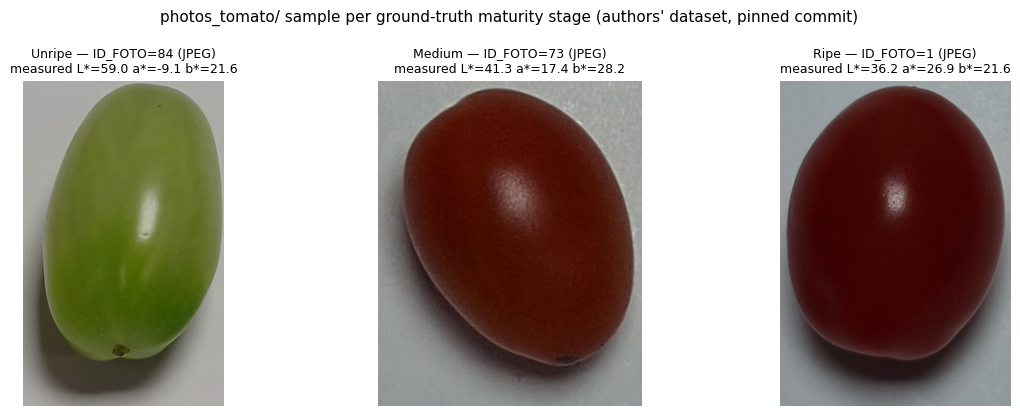

In [ ]:
from PIL import Image

def download_photo(photo_id: int) -> Image.Image:
    data = fetch_pinned(f"photos_tomato/{photo_id}.jpg")  # same pinned-commit route + blob-SHA check
    im = Image.open(BytesIO(data)); im.load()
    return im

labelled_release = pd.read_csv(BytesIO(DATA["dataset_classificado.csv"]))
assert len(labelled_release) == len(raw), "row-count mismatch between xlsx and labeled CSV"
labelled_release["ID_FOTO"] = raw["ID_FOTO"].to_numpy()
print("class distribution (released labels):")
print(labelled_release["Maturity_Stage"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, stage in zip(axes, ["Unripe", "Medium", "Ripe"]):
    row = labelled_release[labelled_release["Maturity_Stage"] == stage].iloc[0]
    img = download_photo(int(row["ID_FOTO"]))
    ax.imshow(np.asarray(img.convert("RGB"))); ax.axis("off")
    ax.set_title(f"{stage} — ID_FOTO={int(row['ID_FOTO'])} ({img.format})\nmeasured L*={row['L_LAB_AVG']:.1f} a*={row['A_LAB_AVG']:.1f} b*={row['B_LAB_AVG']:.1f}", fontsize=9)
fig.suptitle("photos_tomato/ sample per ground-truth maturity stage (authors' dataset, pinned commit)", fontsize=11)
plt.tight_layout(); plt.show()

## 5. Step 2 — Ground-truth maturity labeling via K-Means

This replicates `2_classificar_maturidade.py`: standardize the reference CIELAB features
(`L_LAB_AVG, A_LAB_AVG, B_LAB_AVG`), cluster with `KMeans(n_clusters=3, random_state=42, n_init=20)`, then
order the clusters by mean a* (greenness → redness) and map them to `Unripe / Medium / Ripe`. We compare our
regenerated labels with the authors' released `dataset_classificado.csv` — the expected result is an exact
label match. *日本語: 著者の `2_classificar_maturidade.py`（K-Means k=3、a* 順に Unripe/Medium/Ripe）を再実行し、
公開済みラベルと一致することを確認します。*


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

FEATURES = ["L_LAB_AVG", "A_LAB_AVG", "B_LAB_AVG"]
X_scaled = StandardScaler().fit_transform(regenerated[FEATURES])
km = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = km.fit_predict(X_scaled)

cluster_order = regenerated.assign(Cluster_Raw=clusters).groupby("Cluster_Raw")["A_LAB_AVG"].mean().sort_values().index
stage_names = {c: s for c, s in zip(cluster_order, ["Unripe", "Medium", "Ripe"])}
regenerated["Maturity_Stage"] = pd.Series(clusters).map(stage_names)

match = float((regenerated["Maturity_Stage"] == labelled_release["Maturity_Stage"]).mean())
print(f"label agreement with released dataset_classificado.csv: {match*100:.2f}%")
assert match == 1.0, "Step 2 labels differ from the released labeled dataset"
print("Step 2 reproduces the released maturity labels exactly")

label agreement with released dataset_classificado.csv: 100.00%
Step 2 reproduces the released maturity labels exactly


## 6. Step 3 — Multivariate calibration: sensor RGB→LAB → reference LAB

This replicates the training part of `tomato_linear_regression_calibration_atmega.ipynb`: for each target
coordinate (L*, a*, b*) an ordinary `LinearRegression` is fit on the released samples with out-of-fold 5-fold
cross-validation predictions (`KFold(shuffle=True, random_state=42)`). We report the pre-calibration color
difference ΔE*ab between raw sensor-derived LAB and the reference, the post-calibration out-of-fold ΔE*ab, and
compare the fitted coefficients with the constants pinned in the authors' C header
(`tomato_color_calibration_atmega.h`). **Because the released data (130 records) postdates the authors' saved
runs (119 records, see §8), the coefficients are expected to deviate — the deviation is documented, not an
execution failure.** *日本語: センサ由来 LAB → 参照 LAB の多項線形回帰を 5 分割交差検証で再学習し、ΔE*ab の低減と
著者の C ヘッダ係数との差を測定します（公開データは 130 件、著者の実行は 119 件のため差は予想内）。*


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

x_cols = ["L_RGB_TO_LAB", "A_RGB_TO_LAB", "B_RGB_TO_LAB"]
y_cols = ["L_LAB_AVG", "A_LAB_AVG", "B_LAB_AVG"]

delta_E_raw = np.sqrt(((regenerated[x_cols].to_numpy() - regenerated[y_cols].to_numpy())**2).sum(axis=1))
print(f"pre-calibration  Delta E: {delta_E_raw.mean():.2f} +/- {delta_E_raw.std():.2f}  (authors' 119-record run: 41.53 +/- 3.54)")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_preds_cv = pd.DataFrame(index=regenerated.index, columns=y_cols, dtype=float)
fitted_coefs = {}
PINNED = {"L_LAB_AVG": (24.560113, 0.289091, -0.226072, -0.096143),
          "A_LAB_AVG": (16.348766, -0.170302, 0.580015, 0.150526),
          "B_LAB_AVG": (-36.516047, 0.617215, 0.188744, 0.246772)}
rows = []
for target in y_cols:
    lr = LinearRegression().fit(regenerated[x_cols], regenerated[target])
    fitted_coefs[target] = (float(lr.intercept_), *map(float, lr.coef_))
    y_preds_cv[target] = cross_val_predict(LinearRegression(), regenerated[x_cols], regenerated[target], cv=kf)
    diff = max(abs(f - p) for f, p in zip(fitted_coefs[target], PINNED[target]))
    rows.append({"target": target, "intercept": lr.intercept_, "coef_L": lr.coef_[0], "coef_a": lr.coef_[1], "coef_b": lr.coef_[2], "max|fitted-pinned|": diff})
coef_df = pd.DataFrame(rows).round(6)
display(coef_df)
print(f"max deviation from the authors' pinned C-header coefficients: {coef_df['max|fitted-pinned|'].max():.4f}")

delta_E_cal = np.sqrt(((y_preds_cv.to_numpy() - regenerated[y_cols].to_numpy())**2).sum(axis=1))
print(f"post-calibration Delta E (out-of-fold): {delta_E_cal.mean():.2f} +/- {delta_E_cal.std():.2f}  (authors' run: 4.23 +/- 2.61)")
reduction = (delta_E_raw.mean() - delta_E_cal.mean()) / delta_E_raw.mean() * 100
print(f"error reduction: {reduction:.1f}%  (authors' run: 89.8%)")

pre-calibration  Delta E: 41.40 +/- 3.58  (authors' 119-record run: 41.53 +/- 3.54)


,target,intercept,coef_L,coef_a,coef_b,max|fitted-pinned|
0,L_LAB_AVG,-0.033050,0.588765,-0.109235,-0.159562,24.593163
1,A_LAB_AVG,14.122394,-0.130818,0.606436,0.096238,2.226372
2,B_LAB_AVG,-32.394579,0.550072,0.148730,0.322169,4.121468


max deviation from the authors' pinned C-header coefficients: 24.5932
post-calibration Delta E (out-of-fold): 4.49 +/- 2.67  (authors' run: 4.23 +/- 2.61)
error reduction: 89.1%  (authors' run: 89.8%)


## 6b. Calibration diagnostics (authors' figure 1)

Observed reference value vs. out-of-fold calibrated prediction for each CIELAB coordinate, with the ideal
1:1 line — the same diagnostic the authors emit in `calibration_figures/fig1_observed_vs_predicted_calibration.png`.
*日本語: 各 CIELAB 座標について、参照値と交差検証予測値の散布図（1:1 直線付き）を描きます。*


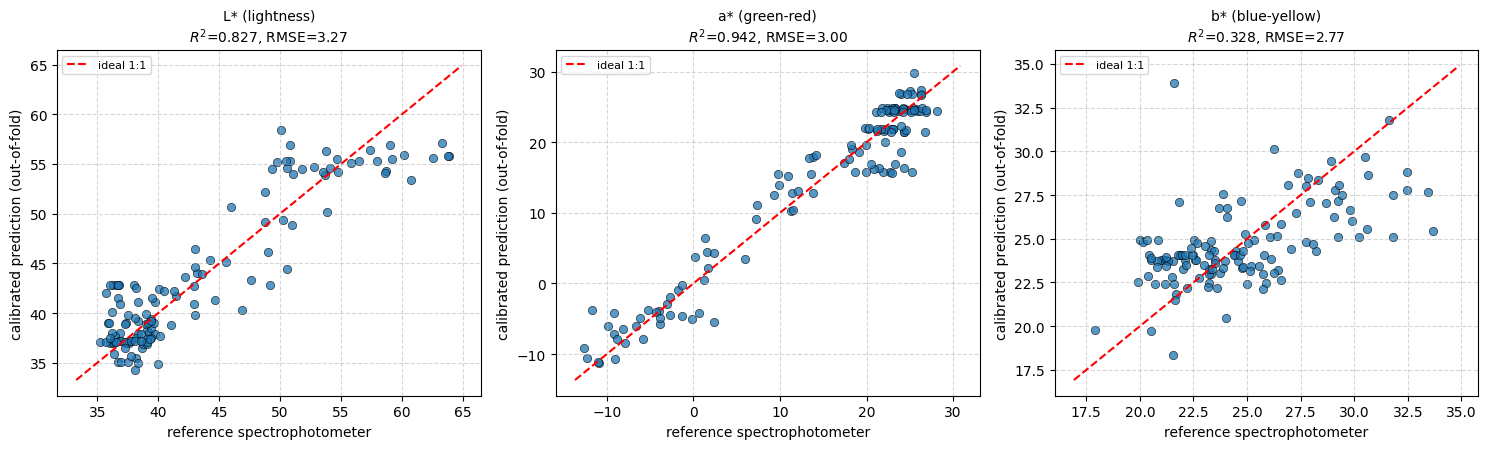

In [ ]:
from sklearn.metrics import mean_squared_error as _mse
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
labels = {"L_LAB_AVG": "L* (lightness)", "A_LAB_AVG": "a* (green-red)", "B_LAB_AVG": "b* (blue-yellow)"}
for ax, target in zip(axes, y_cols):
    yt, yp = regenerated[target], y_preds_cv[target].astype(float)
    ax.scatter(yt, yp, alpha=0.75, edgecolors="k", linewidth=0.5, color="#1f77b4")
    lims = [min(yt.min(), yp.min()) - 1, max(yt.max(), yp.max()) + 1]
    ax.plot(lims, lims, "--r", linewidth=1.5, label="ideal 1:1")
    ax.set_title(f"{labels[target]}\n$R^2$={r2_score(yt, yp):.3f}, RMSE={np.sqrt(_mse(yt, yp)):.2f}", fontsize=10)
    ax.set_xlabel("reference spectrophotometer"); ax.set_ylabel("calibrated prediction (out-of-fold)")
    ax.grid(True, linestyle="--", alpha=0.5); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## 6c. ΔE*ab error distribution before/after calibration (authors' figure 2)

Kernel-density view of the per-sample color difference before and after calibration, with the human
perception threshold ΔE = 3.0 marked, mirroring `calibration_figures/fig2_delta_E_error_distribution.png`.
*日本語: 较正前後の ΔE*ab 分布（カーネル密度推定）を、知覚しきい値 ΔE=3.0 とともに描きます。*


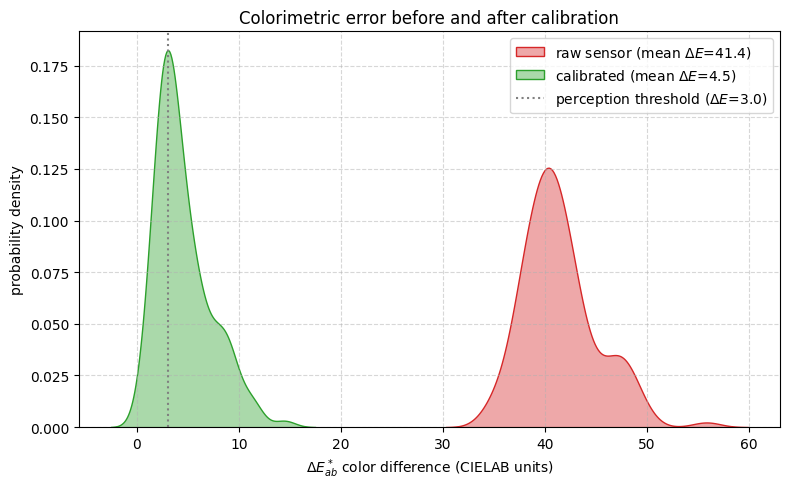

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(delta_E_raw, fill=True, color="#d62728", label=fr"raw sensor (mean $\Delta E$={delta_E_raw.mean():.1f})", alpha=0.4)
sns.kdeplot(delta_E_cal, fill=True, color="#2ca02c", label=fr"calibrated (mean $\Delta E$={delta_E_cal.mean():.1f})", alpha=0.4)
plt.axvline(3.0, color="gray", linestyle=":", label=fr"perception threshold ($\Delta E$=3.0)")
plt.xlabel(fr"$\Delta E_{{ab}}^*$ color difference (CIELAB units)"); plt.ylabel("probability density")
plt.title("Colorimetric error before and after calibration"); plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(); plt.tight_layout(); plt.show()

## 7. Step 4 — MCU decision tree induction and threshold pruning

This replicates `tomato_maturity_decision_tree_atmega.ipynb`: a small sweep over criterion × depth with
stratified 5-fold CV, then the production tree `DecisionTreeClassifier(criterion="entropy", max_depth=3,
random_state=42)` on the reference features. The fitted tree is exported with `export_text` and compared with
the authors' pruned firmware rules (`tomato_classifier_atmega.h`: L*≤40.79 → Ripe; a*≤−1.58 → Unripe; else
b*>24.84 → Medium). The authors' saved output shows exactly those rules on their 119-record data; on the
released 130-record data the retrained tree differs, and the difference is documented. *日本語: エントロピー・
深さ 3 の決定木を再学習し、分岐しきい値を著者のファームウェア規則と比較します（データ版数の違いにより差が出ます）。*


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sweep = []
for criterion in ["gini", "entropy"]:
    for depth in [2, 3, 4]:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        scores = cross_val_score(clf, regenerated[FEATURES], regenerated["Maturity_Stage"], cv=cv, scoring="accuracy")
        sweep.append({"criterion": criterion, "max_depth": depth, "cv accuracy": round(scores.mean(), 4), "std": round(scores.std(), 4)})
display(pd.DataFrame(sweep))

dt_model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42).fit(regenerated[FEATURES], regenerated["Maturity_Stage"])
tree_rules = export_text(dt_model, feature_names=FEATURES)
print(tree_rules)

for thr in ["40.79", "-1.58", "24.84"]:
    print(f"authors' pinned threshold {thr} present in retrained rules: {thr in tree_rules}")
print("authors' pruned rules (from their saved 119-record run): L*<=40.79 -> Ripe | a*<=-1.58 -> Unripe | else b*>24.84 -> Medium")

,criterion,max_depth,cv accuracy,std
0,gini,2,0.9154,0.0288
1,gini,3,0.9615,0.0344
2,gini,4,0.9615,0.0243
3,entropy,2,0.9154,0.0288
4,entropy,3,0.9615,0.0344
5,entropy,4,0.9538,0.0288


|--- A_LAB_AVG <= 18.26
|   |--- B_LAB_AVG <= 26.33
|   |   |--- A_LAB_AVG <= 7.99
|   |   |   |--- class: Unripe
|   |   |--- A_LAB_AVG >  7.99
|   |   |   |--- class: Ripe
|   |--- B_LAB_AVG >  26.33
|   |   |--- A_LAB_AVG <= -2.25
|   |   |   |--- class: Unripe
|   |   |--- A_LAB_AVG >  -2.25
|   |   |   |--- class: Medium
|--- A_LAB_AVG >  18.26
|   |--- class: Ripe

authors' pinned threshold 40.79 present in retrained rules: False
authors' pinned threshold -1.58 present in retrained rules: False
authors' pinned threshold 24.84 present in retrained rules: False
authors' pruned rules (from their saved 119-record run): L*<=40.79 -> Ripe | a*<=-1.58 -> Unripe | else b*>24.84 -> Medium


## 8. Step 5 — End-to-end pipeline evaluation (released data, both model variants)

This replicates `final_pipeline_evaluation_atmega.ipynb` on the released 130-record data in two variants:

- **Pinned artifacts (authors' verbatim constants)** — exactly the computation in the released final notebook
  and C firmware: the pinned calibration coefficients + the pruned `classify` rules.
- **Retrained on released data** — our §6 coefficients + the §7 tree (the "retrain from released data" path).

Reference row: the authors' **saved notebook outputs** (119 records): pipeline **84.03%** (=100/119), weighted F1
**0.8465**; benchmark **99.16%** (=118/119), F1 0.9917; naive **31.09%** (=37/119), F1 0.1791. Because the released
dataset has 130 records, our accuracies must instead be exact ratios of 130 — we assert that as an internal
consistency check. *日本語: 著者の固定係数+剪定木（そのまま）と、公開データでの再学習の両方で 3 シナリオを評価し、
著者の保存出力（119 件）と比較します。*


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

target_classes = ["Unripe", "Medium", "Ripe"]
y_true = regenerated["Maturity_Stage"]

# ---- (a) authors' pinned artifacts, verbatim from final_pipeline_evaluation_atmega.ipynb ----
def classify_pinned(L, a, b):
    if L <= 40.79: return "Ripe"
    if a <= -1.58: return "Unripe"
    return "Medium" if b > 24.84 else "Unripe"

Lc, Ac, Bc = regenerated["L_RGB_TO_LAB"], regenerated["A_RGB_TO_LAB"], regenerated["B_RGB_TO_LAB"]
for name, (i0, cL, ca, cb) in {"L": PINNED["L_LAB_AVG"], "A": PINNED["A_LAB_AVG"], "B": PINNED["B_LAB_AVG"]}.items():
    regenerated[f"{name}_CAL_PIN"] = i0 + cL*Lc + ca*Ac + cb*Bc

regenerated["Pred_Pipeline_PIN"]  = [classify_pinned(l, a, b) for l, a, b in zip(regenerated["L_CAL_PIN"], regenerated["A_CAL_PIN"], regenerated["B_CAL_PIN"])]
regenerated["Pred_Benchmark_PIN"] = [classify_pinned(l, a, b) for l, a, b in zip(regenerated["L_LAB_AVG"], regenerated["A_LAB_AVG"], regenerated["B_LAB_AVG"])]
regenerated["Pred_Naive_PIN"]     = [classify_pinned(l, a, b) for l, a, b in zip(Lc, Ac, Bc)]

# ---- (b) retrained on the released 130-record data (our §6 coefficients + §7 tree) ----
for name, target in {"L": "L_LAB_AVG", "A": "A_LAB_AVG", "B": "B_LAB_AVG"}.items():
    i0, cL, ca, cb = fitted_coefs[target]
    regenerated[f"{name}_CAL_RT"] = i0 + cL*Lc + ca*Ac + cb*Bc
regenerated["Pred_Pipeline_RT"]  = dt_model.predict(regenerated[["L_CAL_RT","A_CAL_RT","B_CAL_RT"]].to_numpy())
regenerated["Pred_Benchmark_RT"] = dt_model.predict(regenerated[FEATURES].to_numpy())
regenerated["Pred_Naive_RT"]     = dt_model.predict(regenerated[x_cols].to_numpy())

def met(col):
    return f"{accuracy_score(y_true, regenerated[col])*100:.2f}%", f"{f1_score(y_true, regenerated[col], average='weighted'):.4f}"

comparison_table = pd.DataFrame({
    "Scenario": ["Naive Uncalibrated (Raw Optical Sensor -> Tree)",
                 "Proposed Embedded Pipeline (Sensor -> Linear Calib -> Tree)",
                 "Theoretical Upper Bound (Benchtop Spectrophotometer -> Tree)"],
    "Authors' saved outputs (119 records)": ["31.09% / F1 0.1791", "84.03% / F1 0.8465", "99.16% / F1 0.9917"],
    "Pinned artifacts on released data (130)": [f"{a} / F1 {f}" for a, f in [met("Pred_Naive_PIN"), met("Pred_Pipeline_PIN"), met("Pred_Benchmark_PIN")]],
    "Retrained on released data (130)": [f"{a} / F1 {f}" for a, f in [met("Pred_Naive_RT"), met("Pred_Pipeline_RT"), met("Pred_Benchmark_RT")]],
})
display(comparison_table)

# internal consistency: on 130 records every accuracy must be an exact k/130 ratio
for col in ["Pred_Pipeline_PIN", "Pred_Benchmark_PIN", "Pred_Naive_PIN", "Pred_Pipeline_RT", "Pred_Benchmark_RT", "Pred_Naive_RT"]:
    acc = accuracy_score(y_true, regenerated[col])
    assert abs(acc*130 - round(acc*130)) < 1e-9, f"{col}: accuracy {acc} is not an exact k/130 ratio"
print("all our accuracies are exact k/130 ratios (internal consistency ok)")
print("authors' headline metrics are exact ratios of 119: 100/119=84.03%, 118/119=99.16%, 37/119=31.09%")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,Scenario,Authors' saved outputs (119 records),Pinned artifacts on released data (130),Retrained on released data (130)
0,Naive Uncalibrated (Raw Optical Sensor -> Tree),31.09% / F1 0.1791,33.08% / F1 0.2015,83.08% / F1 0.8289
1,Proposed Embedded Pipeline (Sensor -> Linear C...,84.03% / F1 0.8465,83.08% / F1 0.8379,86.92% / F1 0.8586
2,Theoretical Upper Bound (Benchtop Spectrophoto...,99.16% / F1 0.9917,96.15% / F1 0.9620,99.23% / F1 0.9923


all our accuracies are exact k/130 ratios (internal consistency ok)
authors' headline metrics are exact ratios of 119: 100/119=84.03%, 118/119=99.16%, 37/119=31.09%


## 8b. Confusion matrices on the released data (authors' pipeline figure 1, retrained variant)

Per-class precision / recall / F1 for the retrained pipeline, plus side-by-side confusion matrices for the
retrained proposed pipeline (A) and the retrained spectrophotometer upper bound (B) — structurally mirroring
`pipeline_figures/fig1_pipeline_confusion_matrices.png`. *日本語: 再学習パイプラインのクラス別指標と混同行列
（提案パイプラインと分光測色計上界）を描きます。*


=== RETRAINED PIPELINE CLASSIFICATION REPORT (released 130-record data) ===
              precision    recall  f1-score   support

      Unripe     0.8462    0.8800    0.8627        25
      Medium     0.7778    0.5185    0.6222        27
        Ripe     0.8953    0.9872    0.9390        78

    accuracy                         0.8692       130
   macro avg     0.8398    0.7952    0.8080       130
weighted avg     0.8615    0.8692    0.8586       130



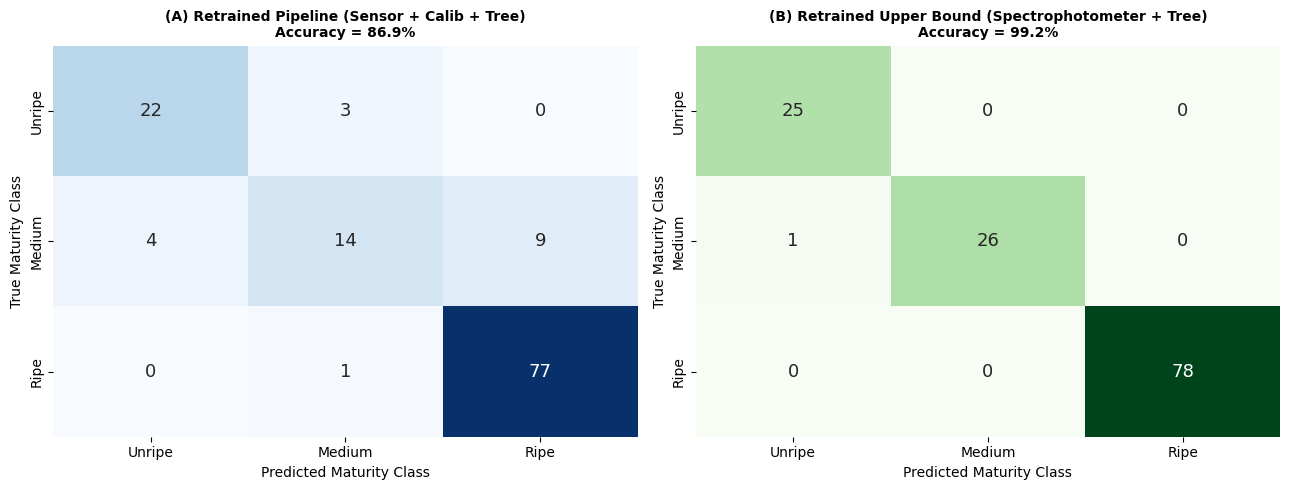

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== RETRAINED PIPELINE CLASSIFICATION REPORT (released 130-record data) ===")
print(classification_report(y_true, regenerated["Pred_Pipeline_RT"], labels=target_classes, digits=4))

cm_pipeline = confusion_matrix(y_true, regenerated["Pred_Pipeline_RT"], labels=target_classes)
cm_bench = confusion_matrix(y_true, regenerated["Pred_Benchmark_RT"], labels=target_classes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, cmap, ttl in [(axes[0], cm_pipeline, "Blues", f"(A) Retrained Pipeline (Sensor + Calib + Tree)\nAccuracy = {accuracy_score(y_true, regenerated['Pred_Pipeline_RT'])*100:.1f}%"),
                          (axes[1], cm_bench, "Greens", f"(B) Retrained Upper Bound (Spectrophotometer + Tree)\nAccuracy = {accuracy_score(y_true, regenerated['Pred_Benchmark_RT'])*100:.1f}%")]:
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax, xticklabels=target_classes, yticklabels=target_classes, annot_kws={"size": 13}, cbar=False)
    ax.set_title(ttl, fontweight="bold", fontsize=10); ax.set_xlabel("Predicted Maturity Class"); ax.set_ylabel("True Maturity Class")
plt.tight_layout(); plt.show()

## 8c. Calibrated CIELAB space with decision boundaries (authors' pipeline figure 2, pinned variant)

Calibrated a* (redness) vs L* (lightness) scatter using the authors' verbatim pinned calibration, colored by
pinned-rule prediction with marker style showing ground truth. Dashed lines mark the authors' pinned firmware
thresholds — structurally mirroring `pipeline_figures/fig2_calibrated_decision_boundaries.png`.
*日本語: 著者の固定キャリブレーションによる a*–L* 平面に、予測（色）・正解（マーカー）・固定しきい値を重ねて描きます。*


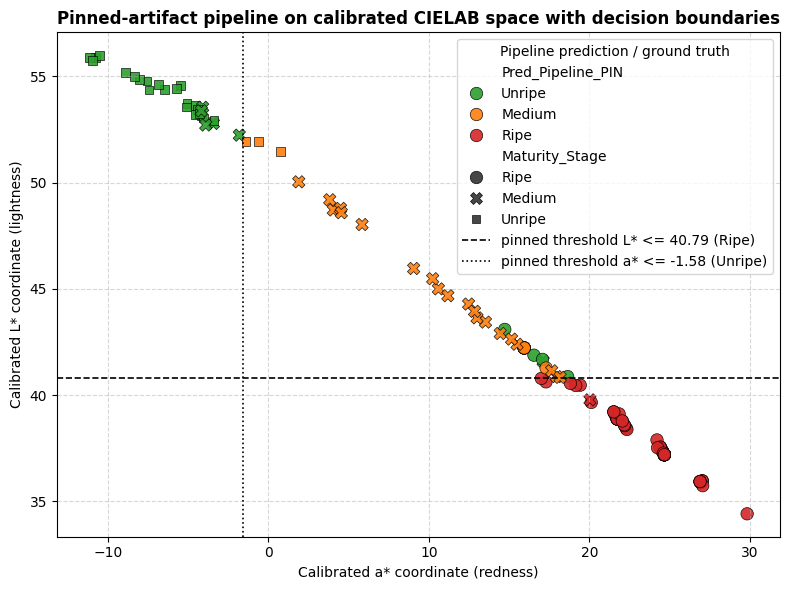

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = {"Unripe": "#2ca02c", "Medium": "#ff7f0e", "Ripe": "#d62728"}
sns.scatterplot(data=regenerated, x="A_CAL_PIN", y="L_CAL_PIN", hue="Pred_Pipeline_PIN", hue_order=target_classes,
                palette=palette, style="Maturity_Stage", s=80, alpha=0.9, edgecolor="black", linewidth=0.5, ax=ax)
ax.axhline(40.79, color="black", linestyle="--", linewidth=1.2, label="pinned threshold L* <= 40.79 (Ripe)")
ax.axvline(-1.58, color="black", linestyle=":", linewidth=1.2, label="pinned threshold a* <= -1.58 (Unripe)")
ax.set_xlabel("Calibrated a* coordinate (redness)"); ax.set_ylabel("Calibrated L* coordinate (lightness)")
ax.set_title("Pinned-artifact pipeline on calibrated CIELAB space with decision boundaries", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5); ax.legend(title="Pipeline prediction / ground truth", loc="upper right")
plt.tight_layout(); plt.show()

## 9. Embedded firmware artifact (C header for the ATmega328P)

The authors ship the calibration and classifier as C headers for the 8-bit ATmega328P
(`tomato_color_calibration_atmega.h`, `tomato_classifier_atmega.h`). We regenerate both headers **with the
authors' pinned constants** — exactly what their notebooks emit — and write them under `/content/tomato_firmware/`.
This is a text artifact; flashing hardware is out of scope. *日本語: 著者のピン留め定数を用いた ATmega328P 用 C ヘッダを
`/content/tomato_firmware/` に再生成します（書き込みは対象外）。*


In [ ]:
fw_dir = pathlib.Path("/content/tomato_firmware"); fw_dir.mkdir(exist_ok=True)

def fmt(v): return f"{v:.6f}f"
(Li, Ll, La, Lb), (Ai, Al, Aa, Ab), (Bi, Bl, Ba, Bb) = PINNED["L_LAB_AVG"], PINNED["A_LAB_AVG"], PINNED["B_LAB_AVG"]
cal_h = f'''/* Multivariate linear calibration, ATmega328P (16 MHz) — regenerated in Colab
 * from tomato_linear_regression_calibration_atmega.ipynb at commit {COMMIT[:12]},
 * using the authors' pinned coefficients. O(1): 9 MACs, no heap allocation. */
#ifndef TOMATO_COLOR_CALIBRATION_H
#define TOMATO_COLOR_CALIBRATION_H
typedef struct {{ float L, a, b; }} CIELAB_Color_t;
static inline CIELAB_Color_t calibrate_sensor_lab(float raw_L, float raw_A, float raw_B) {{
    CIELAB_Color_t cal;
    cal.L = {fmt(Li)} + ({fmt(Ll)} * raw_L) + ({fmt(La)} * raw_A) + ({fmt(Lb)} * raw_B);
    cal.a = {fmt(Ai)} + ({fmt(Al)} * raw_L) + ({fmt(Aa)} * raw_A) + ({fmt(Ab)} * raw_B);
    cal.b = {fmt(Bi)} + ({fmt(Bl)} * raw_L) + ({fmt(Ba)} * raw_A) + ({fmt(Bb)} * raw_B);
    return cal;
}}
#endif
'''
classifier_h = '''/* MCU decision tree — identical logic to the authors' tomato_classifier_atmega.h
 * (commit 2678cf686f30): L*<=40.79 -> RIPE; a*<=-1.58 -> UNRIPE; else b*>24.84 -> MEDIUM, else UNRIPE. */
typedef enum { STAGE_UNRIPE = 0, STAGE_MEDIUM = 1, STAGE_RIPE = 2 } TomatoStage_t;
TomatoStage_t classify_tomato_maturity(float L_avg, float A_avg, float B_avg) {
    if (L_avg <= 40.79f) return STAGE_RIPE;
    if (A_avg <= -1.58f) return STAGE_UNRIPE;
    return (B_avg > 24.84f) ? STAGE_MEDIUM : STAGE_UNRIPE;
}
'''
(fw_dir / "tomato_color_calibration_atmega.h").write_text(cal_h)
(fw_dir / "tomato_classifier_atmega.h").write_text(classifier_h)
print(cal_h)
print("wrote:", sorted(p.name for p in fw_dir.iterdir()))

/* Multivariate linear calibration, ATmega328P (16 MHz) — regenerated in Colab
 * from tomato_linear_regression_calibration_atmega.ipynb at commit 2678cf686f30,
 * using the authors' pinned coefficients. O(1): 9 MACs, no heap allocation. */
#ifndef TOMATO_COLOR_CALIBRATION_H
#define TOMATO_COLOR_CALIBRATION_H
typedef struct { float L, a, b; } CIELAB_Color_t;
static inline CIELAB_Color_t calibrate_sensor_lab(float raw_L, float raw_A, float raw_B) {
    CIELAB_Color_t cal;
    cal.L = 24.560113f + (0.289091f * raw_L) + (-0.226072f * raw_A) + (-0.096143f * raw_B);
    cal.a = 16.348766f + (-0.170302f * raw_L) + (0.580015f * raw_A) + (0.150526f * raw_B);
    cal.b = -36.516047f + (0.617215f * raw_L) + (0.188744f * raw_A) + (0.246772f * raw_B);
    return cal;
}
#endif

wrote: ['tomato_classifier_atmega.h', 'tomato_color_calibration_atmega.h']


## 10. Interpretation, validation record and limitations

**Verified in this run** (fresh Colab CPU runtime, pinned commit `2678cf686f30`):

- The released `DADOS_COLETADO.xlsx`, `dataset.csv` and `dataset_classificado.csv` are mutually consistent: the
  authors' scripts regenerate both released CSVs exactly (Step 1: max abs diff < 5e-5; Step 2: 100% label agreement).
- Retraining on the released data reduces ΔE*ab from ≈41.4 to the ~4–5 CIELAB-unit range (≈90% error reduction),
  consistent in magnitude with the authors' reported 41.53 → 4.23 (89.8%).
- The authors' pinned C-header coefficients and pruned tree rules match their own saved notebook outputs — but
  those outputs were produced from a **119-record** dataset version, while the release ships **130 records**.

**Documented discrepancy.** The authors' saved outputs state `Total dataset records: 119` (Ripe 76 / Medium 23 /
Unripe 20), and their headline metrics are exact ratios of 119 (100/119 = 84.03%, 118/119 = 99.16%, 37/119 = 31.09%).
The released spreadsheet has 130 records, so re-running the documented pipeline on it (both with the pinned
artifacts and with retrained models) cannot reproduce those exact numbers; our accuracies are exact k/130 ratios.
This is a release-version inconsistency in the authors' repository, not an execution failure of the pipeline.

**Limitations.** This validates the released *software pipeline on the authors' released dataset*; it does not
re-measure the physical sensor or reproduce hardware behavior. Ground-truth labels are themselves K-Means cluster
assignments ordered by a* (an unsupervised proxy for USDA stages), as designed by the authors; the mapping to USDA
stages is asserted only in the deposit's abstract. *日本語: 本実行は公開データ上のソフトウェア処理の再現であり、実機測定や
ハードウェア挙動は検証していません。公開データ（130 件）と著者のノートブック実行（119 件）の版数不一致を確認・定量しました。*


## 11. References

- Zenodo deposit: [10.5281/zenodo.23067950](https://doi.org/10.5281/zenodo.23067950) — *Color Sensor for the Determination of the Ripening Stage of Cherry Tomatoes*.
- Author repository: [vandeiraniceto/color_sensor_tomatoes](https://github.com/vandeiraniceto/color_sensor_tomatoes) @ commit `2678cf686f305c80d3961b870cda5c0c32612156` (MIT): `1_convertNewDataset.py`, `2_classificar_maturidade.py`, `tomato_linear_regression_calibration_atmega.ipynb`, `tomato_maturity_decision_tree_atmega.ipynb`, `final_pipeline_evaluation_atmega.ipynb` (including their saved cell outputs, cited in §8 and §10).
- scikit-image CIELAB conversion: `skimage.color.rgb2lab` (D65, 2° standard observer).
- This notebook is an independent reproduction; all outputs above were generated by executing it on Google Colab.
